## Imports

In [1]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import plotly.express as px
import re

## Read Data

In [2]:
finnhub_data = pd.read_csv('Data/finnhub_model_input.csv')
finnhub_data['date'] = pd.to_datetime(finnhub_data['date'], errors='coerce')
if 'date_only' not in finnhub_data.columns:
    finnhub_data['date_only'] = finnhub_data['date'].dt.date

print('Loaded new dataset: Data/finnhub_model_input.csv')

Loaded new dataset: Data/finnhub_model_input.csv


## Quick schema check

In [3]:
print('finnhub shape:', finnhub_data.shape)
print('\nfinnhub columns:', list(finnhub_data.columns))
display(finnhub_data[['stock', 'headline', 'date', 'date_only']].head(2))

finnhub shape: (5006, 5)

finnhub columns: ['stock', 'date', 'date_only', 'headline', 'headline_raw']


,stock,headline,date,date_only
0,ING,What are share buybacks?,2024-09-17 15:00:55,2024-09-17
1,SMFG,PBOC Seen Deploying Stimulus Soon on Tariff Ri...,2025-04-02 03:26:24,2025-04-02


## Exploratory data analysis

,missing_count
stock,0
headline,0
date_only,0


Date range combined: 2024-09-17 -> 2026-03-28
Unique stocks: 27


,n_records
stock,
BCS,248
DB,248
MUFG,248
JPM,247
GS,246
SAN,243
HSBC,242
MS,242
RY,241


,headline_len_stats
count,5006.000000
mean,77.873951
std,35.373807
min,10.000000
25%,60.000000
50%,71.000000
75%,87.000000
max,487.000000


,date_only,n_records
334,2026-03-19,150
335,2026-03-20,115
336,2026-03-21,35
337,2026-03-22,20
338,2026-03-23,98
339,2026-03-24,108
340,2026-03-25,127
341,2026-03-26,116
342,2026-03-27,102
343,2026-03-28,35


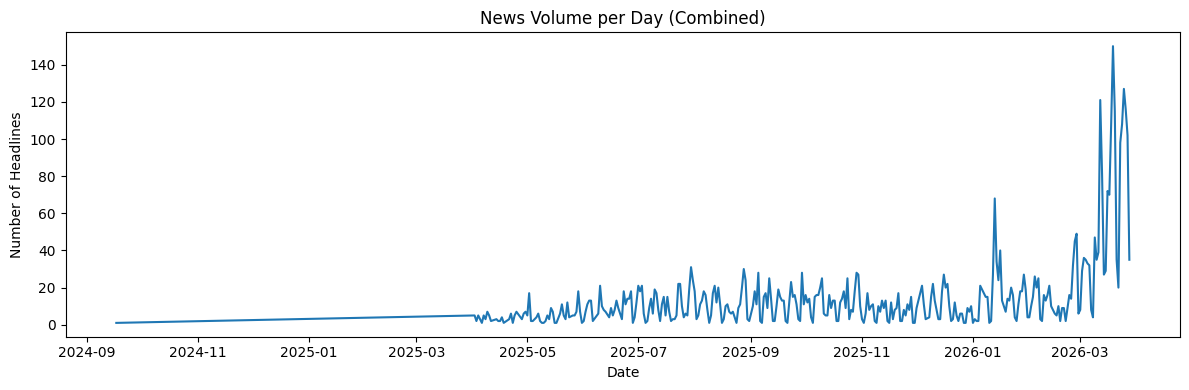

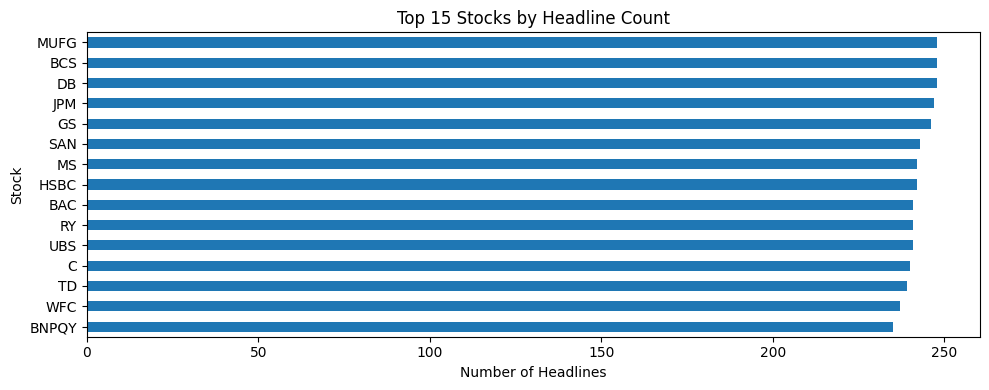

In [4]:
# quality checks
display(finnhub_data[['stock', 'headline', 'date_only']].isna().sum().to_frame('missing_count'))
print('Date range combined:', finnhub_data['date_only'].min(), '->', finnhub_data['date_only'].max())
print('Unique stocks:', finnhub_data['stock'].nunique())

# top stocks
top_stocks = finnhub_data['stock'].value_counts().head(15)
display(top_stocks.rename_axis('stock').to_frame('n_records'))

# headline length
finnhub_data['headline_len'] = finnhub_data['headline'].str.len()
display(finnhub_data['headline_len'].describe().to_frame('headline_len_stats'))

# daily volume
daily_counts = finnhub_data.groupby('date_only').size().rename('n_records').reset_index()
display(daily_counts.tail(10))

try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 4))
    plt.plot(pd.to_datetime(daily_counts['date_only']), daily_counts['n_records'])
    plt.title('News Volume per Day (Combined)')
    plt.xlabel('Date')
    plt.ylabel('Number of Headlines')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    top_stocks.sort_values().plot(kind='barh')
    plt.title('Top 15 Stocks by Headline Count')
    plt.xlabel('Number of Headlines')
    plt.ylabel('Stock')
    plt.tight_layout()
    plt.show()
except Exception as error:
    print('Plotting skipped:', error)

## Wordcloud

Using text column for EDA/wordcloud: headline



Generating word cloud for headlines...


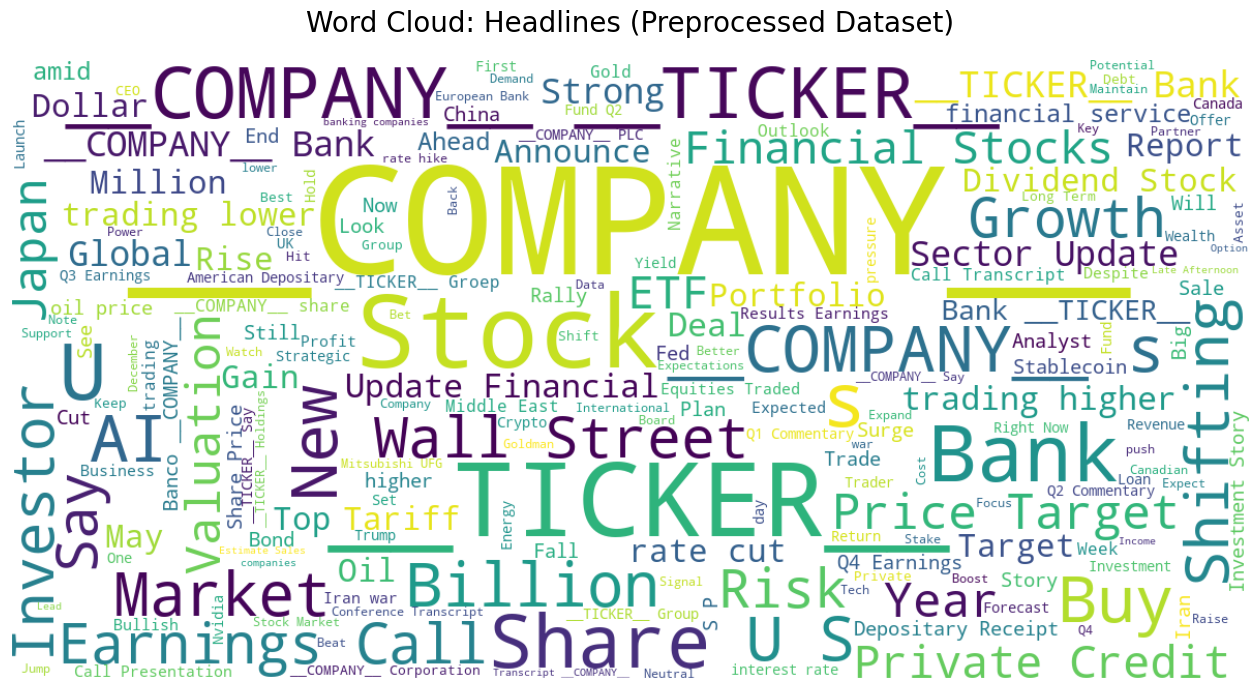

In [5]:
headline_col = 'headline'
print(f'Using text column for EDA/wordcloud: {headline_col}')

# Clean and extract keywords from titles
def extract_keywords(text):
    if pd.isna(text):
        return []
    words = re.findall(r'\b[a-z]{2,}\b', str(text).lower())
    stop_words = {'we', 'il', 'll', 'as', 'it', 'vs', 'at', 'be', 'our', 'use', 'or', 'let', 'but', 'us', 'by', 'more', 'come', 'have', 'the', 'and', 'for', 'with', 'how', 'your', 'using', 'from', 'into', 'this', 'that', 'are', 'was', 'you', 'what', 'can', 'in', 'to', 'of', 'is', 'an', 'do', 'de', 'on', 'not', 'why', 'will'}
    return [w for w in words if w not in stop_words]

all_summary_words = []
for summary in finnhub_data[headline_col].dropna():
    all_summary_words.extend(extract_keywords(summary))

summary_word_freq = Counter(all_summary_words)
top_summary_words = pd.DataFrame(summary_word_freq.most_common(20), columns=['keyword', 'frequency'])

fig2 = px.bar(
    top_summary_words,
    x='keyword',
    y='frequency',
    title='Top 20 Keywords in Headlines (Preprocessed Dataset)',
    labels={'keyword': 'Keyword', 'frequency': 'Frequency'},
    color='frequency',
    color_continuous_scale='Viridis'
 )
fig2.update_layout(showlegend=False, height=500)
fig2.show(renderer='iframe')

print("\nGenerating word cloud for headlines...")
title_text = ' '.join(finnhub_data[headline_col].dropna().astype(str))
wordcloud_title = WordCloud(width=1200, height=600, background_color='white', colormap='viridis').generate(title_text)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud_title, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Headlines (Preprocessed Dataset)', fontsize=20, pad=20)
plt.tight_layout()
plt.show()

In [8]:
# Average headline length (characters + words)
import pandas as pd

if 'finnhub_data' in globals() and 'headline' in finnhub_data.columns:
    headlines = finnhub_data['headline'].dropna().astype(str)
else:
    tmp_df = pd.read_csv('Data/finnhub_news.csv')
    headlines = tmp_df['headline'].dropna().astype(str)

avg_chars = headlines.str.len().mean()
avg_words = headlines.str.split().str.len().mean()
min_words = headlines.str.split().str.len().min()
max_words = headlines.str.split().str.len().max()

print(f"Headlines analyzed: {len(headlines):,}")
print(f"Average headline length: {avg_chars:.2f} characters")
print(f"Average headline length: {avg_words:.2f} words")
print(f"Minimum headline length: {min_words} words")
print(f"Maximum headline length: {max_words} words")

Headlines analyzed: 5,006
Average headline length: 77.87 characters
Average headline length: 11.95 words
Minimum headline length: 2 words
Maximum headline length: 75 words
